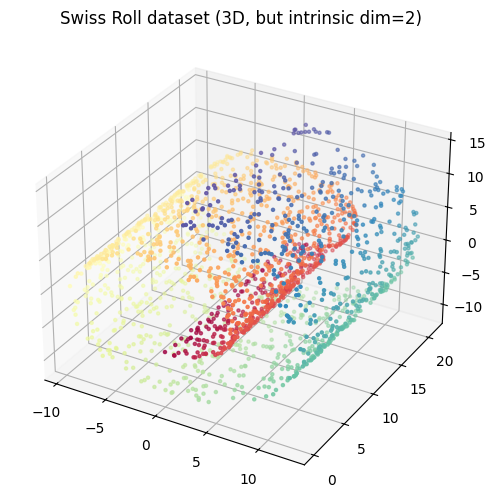

{'MLE': 2.058153199953551,
 'lPCA': 3,
 'KNN': 1,
 'Correlation': 1.916794084431631,
 'Fisher': 2.8916722383517914,
 'MOM': 2.05621592259281,
 'MST': 1.993947093799096}

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
import skdim
from functions import estimate_id_mst

# --- Generate some synthetic high-dimensional data ---
# Swiss roll has intrinsic dimension 2, but is embedded in 3D
X, color = make_swiss_roll(n_samples=2000, noise=0.05)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Spectral, s=5)
ax.set_title("Swiss Roll dataset (3D, but intrinsic dim=2)")
plt.show()

# --- Intrinsic dimension estimation methods ---

def id_ests(X):
    return {'MLE': skdim.id.MLE().fit_transform(X).item(), 
            "lPCA": skdim.id.lPCA().fit_transform(X).item(), 
            "KNN": skdim.id.KNN().fit_transform(X).item(), 
            "Correlation": skdim.id.CorrInt().fit_transform(X).item(),
            "Fisher": skdim.id.FisherS().fit_transform(X).item(),
            "MOM": skdim.id.MOM().fit_transform(X).item(),
            'MST': estimate_id_mst(X, n_subsamples=20,n_repeats=2)['d_hat']}

import skdim

# ---- temporary patch for Python 3.13 locals() change ----
try:
    from skdim.id._MLE import MLE as _MLE

    def _patched_init(self, dnoise=None, sigma=None, n=None,
                      integral_approximation="Haro", unbiased=False,
                      neighborhood_based=True, K=10):
        # avoid using locals(); set attributes explicitly
        self.dnoise = dnoise
        self.sigma = sigma
        self.n = n
        self.integral_approximation = integral_approximation
        self.unbiased = unbiased
        self.neighborhood_based = neighborhood_based
        self.K = K

    _MLE.__init__ = _patched_init
except Exception:
    pass
# ---------------------------------------------------------

id_ests(X)


In [16]:
### let's look at grid data
from itertools import product
from functions import *
from functions import grid_dataset


X = grid_dataset(m=4, d=2, D=8, rotate= True)

id_ests(X)

{'MLE': 1.5830691102610048,
 'lPCA': 2,
 'KNN': 3,
 'Correlation': 0.7195550422589729,
 'Fisher': 1.974022922079353,
 'MOM': 1.4978401073726566,
 'MST': 113.26755219637242}

In [17]:
from tqdm import tqdm

D = 100
n = 300
ds = [i for i in range(2,12)]
pred_ds = []
for d in tqdm(ds):
    m = int(np.log(n) / np.log(d))
    X = grid_dataset(m, d, D, rotate= True)
    pred_ds.append(id_ests(X))

100%|██████████| 10/10 [00:08<00:00,  1.20it/s]


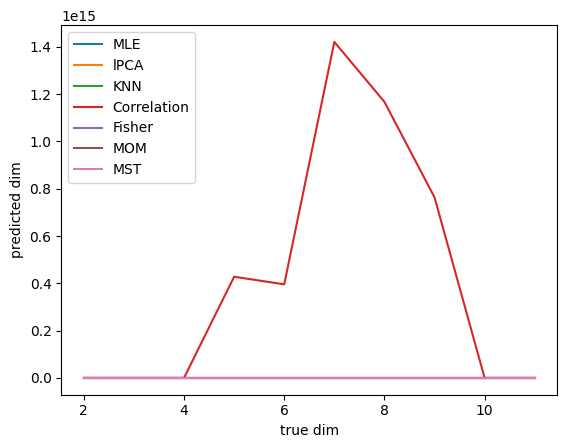

In [18]:
inv_pred_ds = {key: [d[key] for d in pred_ds] for key in pred_ds[0]}
for k in inv_pred_ds.keys():
    plt.plot( ds, inv_pred_ds[k], label=k )
    plt.xlabel('true dim')
    plt.ylabel('predicted dim')
    plt.legend()
#plt.plot( ds, ds, label='truth' )

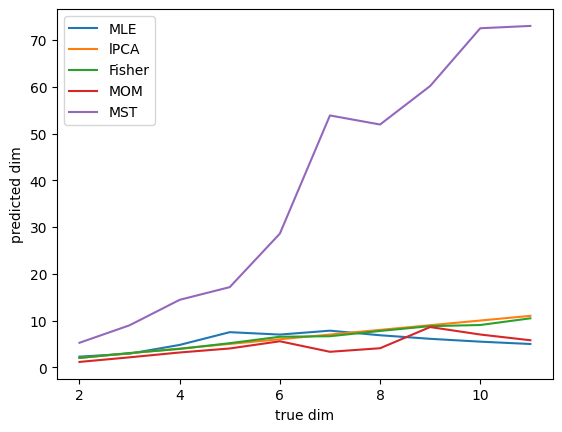

In [19]:
inv_pred_ds = {key: [d[key] for d in pred_ds] for key in pred_ds[0]}
for k in inv_pred_ds.keys():
    if k!= 'Correlation' and k!= 'KNN':
        plt.plot( ds, inv_pred_ds[k], label=k )
        plt.xlabel('true dim')
        plt.ylabel('predicted dim')
        plt.legend()

100%|██████████| 98/98 [00:24<00:00,  4.00it/s]


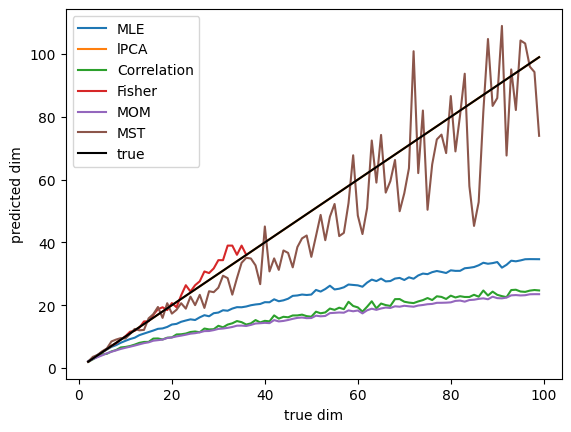

In [20]:

from tqdm import tqdm

D = 200
n = 300
ds = [i for i in range(2,100)]
pred_ds = []
for d in tqdm(ds):
    X = synthetic_subspace(D,d,n,signal_scale=1,noise_scale=0)
    pred_ds.append(id_ests(X))


inv_pred_ds = {key: [d[key] for d in pred_ds] for key in pred_ds[0]}
for k in inv_pred_ds.keys():
    if k!= 'KNN':
        plt.plot( ds, inv_pred_ds[k], label=k )
        plt.xlabel('true dim')
        plt.ylabel('predicted dim')
plt.plot(ds, ds, label='true', c='black')
plt.legend()

100%|██████████| 48/48 [00:10<00:00,  4.39it/s]


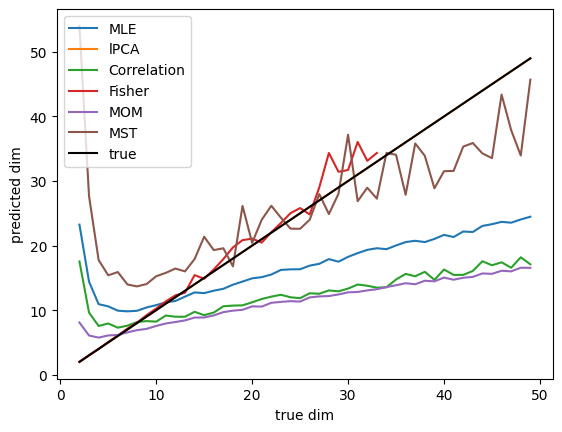

In [21]:
from tqdm import tqdm

D = 200
n = 300
ds = [i for i in range(2,50)]
pred_ds = []
for d in tqdm(ds):
    X = synthetic_subspace(D,d,n, signal_scale=1, noise_scale = 1 / D**0.5)
    pred_ds.append(id_ests(X))


inv_pred_ds = {key: [d[key] for d in pred_ds] for key in pred_ds[0]}
for k in inv_pred_ds.keys():
    if k!= 'KNN':
        plt.plot( ds, inv_pred_ds[k], label=k )
        plt.xlabel('true dim')
        plt.ylabel('predicted dim')
plt.plot(ds, ds, label='true', c='black')
plt.legend()

now let's look at single cell data!

In [22]:
import numpy as np
import scanpy as sc

# PBMC 3k dataset (10x Genomics)
X_pbmc3k = np.asarray( sc.datasets.pbmc3k().X.todense() )

skdim.id.MLE().fit_transform(X_pbmc3k).item()
estimate_id_mst(X_pbmc3k, n_subsamples=20,n_repeats=2)['d_hat']

34.94413890217104

In [3]:
import numpy as np
import scanpy as sc
from tqdm import tqdm
import matplotlib.pyplot as plt
import skdim
from functions import estimate_id_mst

def preprocess_adata(adata, n_top_genes=2000, scale=True, n_pcs=100, seed=0):
    """
    Standard single-cell preprocessing → PCA embedding in adata.obsm['X_pca'].
    Returns the same AnnData with PCA computed.
    """
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, subset=True, flavor="seurat_v3")
    if scale:
        sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack", random_state=seed)
    return adata

def run_id_suite(X, k=20, safe=True,):
    """
    Run a small suite of ID estimators on a 2D np.array (n_samples x n_features).
    Returns a dict {name: estimate or error_string}.
    """
    def call(fn, name):
        if not safe:
            return fn()
        try:
            return fn()
        except Exception as e:
            return f"ERROR: {type(e).__name__}: {e}"
        
        # Core estimators
    ests = {
        "MLE":       lambda: skdim.id.MLE().fit_transform(X).item(),
        "lPCA":      lambda: skdim.id.lPCA().fit_transform(X).item(),
        "KNN":       lambda: skdim.id.KNN(k=k).fit_transform(X).item(),
        "CorrInt":   lambda: skdim.id.CorrInt().fit_transform(X).item(),
        "FisherS":   lambda: skdim.id.FisherS().fit_transform(X).item(),
        "MOM":       lambda: skdim.id.MOM().fit_transform(X).item(),
        "TwoNN":   lambda: skdim.id.TwoNN().fit_transform(X).item(),
        "MST":     lambda: estimate_id_mst(X, n_subsamples=20, n_repeats=2)['d_hat'],
    }

    return {name: call(fn, name) for name, fn in ests.items()}

def evaluate_on_pcs(adata, pcs_list=(10, 20, 30, 40, 50)):
    """
    Evaluate ID across different PCA cutoffs; returns a list of dict rows.
    Each row: {'n_pcs': int, 'n_cells': int, 'estimator': str, 'estimate': float/str}
    """
    rows = []
    X_full = adata.obsm["X_pca"]
    for n_pcs in pcs_list:
        n_pcs = min(n_pcs, X_full.shape[1])
        X = X_full[:, :n_pcs]
        res = run_id_suite(X)
        for name, val in res.items():
            rows.append({
                "n_pcs": n_pcs,
                "n_cells": X.shape[0],
                "estimator": name,
                "estimate": val
            })
    return rows

def plot_estimates(rows, title="ID vs #PCs"):
    """
    Simple line plot of ID estimates vs n_pcs for each estimator.
    """
    # Group by estimator
    by_est = {}
    for r in rows:
        by_est.setdefault(r["estimator"], []).append((r["n_pcs"], r["estimate"]))
    plt.figure(figsize=(7,5))
    for name, pairs in tqdm(by_est.items()):
        pairs = sorted(pairs, key=lambda t: t[0])
        xs = [p[0] for p in pairs]
        ys = [p[1] if isinstance(p[1], (float, int, np.floating)) else np.nan for p in pairs]
        plt.plot(xs, ys, label=name)
    plt.xlabel("# PCs")
    plt.ylabel("Estimated intrinsic dimension")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def load_pbmc3k():
    ad = sc.datasets.pbmc3k()      # cells x genes (sparse)
    return ad



=== PBMC 3k ===
Estimator → median ID over PC sweep
lPCA      : 13.00 (n=5)
KNN       : 20.00 (n=5)
CorrInt   : 7.10 (n=5)
FisherS   : 2.36 (n=5)
MOM       : 10.75 (n=5)
TwoNN     : 16.91 (n=5)
MST       : 14.06 (n=5)


100%|██████████| 8/8 [00:00<00:00, 754.51it/s]


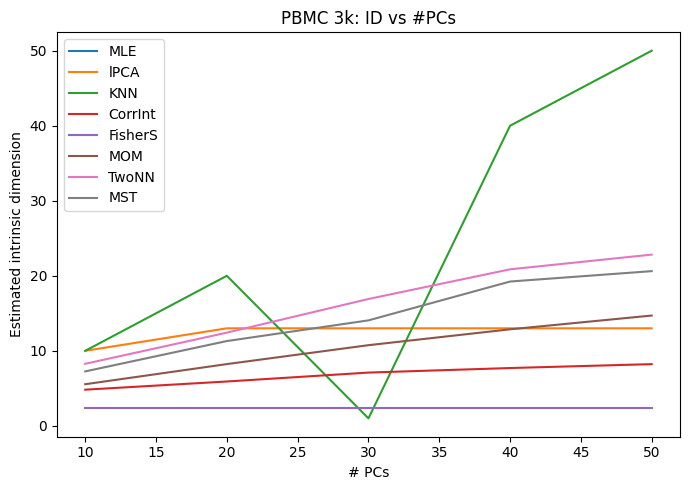

In [4]:
# Choose dataset loader(s)
loaders = [
    ("PBMC 3k", load_pbmc3k),
]

for name, loader in loaders:
    print(f"\n=== {name} ===")
    adata = loader()

    # Preprocess → PCA (store in adata.obsm['X_pca'])
    adata = preprocess_adata(adata, n_top_genes=2000, scale=True, n_pcs=100, seed=0)

    # Evaluate a sweep of PCs; choose k around 10–30
    rows = evaluate_on_pcs(adata, pcs_list=[10,20,30,40,50])

    # Print a compact table (median across PC choices can be useful)
    from collections import defaultdict
    vals = defaultdict(list)
    for r in rows:
        if isinstance(r["estimate"], (float, int, np.floating)):
            vals[r["estimator"]].append(float(r["estimate"]))
    print("Estimator → median ID over PC sweep")
    for est, v in vals.items():
        print(f"{est:10s}: {np.median(v):.2f} (n={len(v)})")

    # Plot ID vs #PCs for a quick stability check
    plot_estimates(rows, title=f"{name}: ID vs #PCs")